## SimCell — module overview (docstring header)


In [1]:
"""
simcell_simulation.py
=====================
Kinetic ODE simulation of the synthetic E. coli SimCell.

Metabolic map
-------------
  lac_e ──[lldP / glycolate permease] ─────────────────► lac_c
  lac_c ──[lldD + PDH: aceE/aceF/lpdA] ───────────────► AcCoA
  AcCoA ──[TCA + ETC lumped] ─────────────────────────► ATP
  AcCoA ──[ArgA → ArgH] ──────────────────────────────► arg_c
  arg_c ──[ArgO / LysE] ──────────────────────────────► arg_e
  ADP   ──[PPK, polyP → ATP] ─────────────────────────► ATP

State vector
------------
   0  lac_c     intracellular L-lactate (mM)
   1  nh4_c     intracellular ammonium (mM)
   2  accoa     acetyl-CoA (mM)
   3  arg_c     intracellular L-arginine (mM)
   4  atp       ATP (mM)    } conserved: atp + adp = A_tot
   5  adp       ADP (mM)    }
   6  polyp     polyphosphate (mM)
   7  lac_e     extracellular lactate (mM)
   8  nh4_e     extracellular ammonium (mM)
   9  arg_e     extracellular arginine (mM)
  10  P_lacT    lldP + glycolate permease (mg/L)
  11  P_P1      lldD + PDH (mg/L)
  12  P_tca     TCA enzymes (mg/L)
  13  P_P2      ArgD-H enzymes (mg/L)
  14  P_argT    ArgO exporter (mg/L)
  15  P_ppk     PPK (mg/L)
  16  n_atp_eff effective ETC ATP yield (decays, no synthesis)

Units: mM (concentrations), hr (time), mg/L (protein), mM/hr (fluxes)
"""

import time
import warnings
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path("output") / "SimCell_sim"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figure output directory: {OUTPUT_DIR.resolve()}")

# =============================================================================
# PARAMETERS


Figure output directory: C:\Users\bcsma\OneDrive - Imperial College London\Documents\Ben\Post-doc\SimCells-for-Cultured-Meat\output\SimCell_sim


## Protein decay rates (`DECAY_RATES`, `PROTEIN_DECAY_MAP`)


In [2]:
# =============================================================================

DECAY_RATES = dict(
    D_cyto = 0.003,   # hr⁻¹ cytoplasmic protein decay
    D_mem  = 0.003,   # hr⁻¹ membrane protein decay
    D_etc  = 0.003,   # hr⁻¹ ETC complex decay
)

# Decay-rate class assigned to each protein pool
PROTEIN_DECAY_MAP = dict(
    P_lacT = "D_mem",    # lldP + glycolate permease
    P_P1   = "D_cyto",   # lldD + PDH
    P_tca  = "D_cyto",   # TCA cycle enzymes
    P_P2   = "D_cyto",   # ArgD-H
    P_argT = "D_mem",    # ArgO
    P_ppk  = "D_cyto",   # PPK
)

N_PROTEIN_CLASSES = len(PROTEIN_DECAY_MAP)


# All k in mmol hr⁻¹ mg⁻¹ unless noted.
K_PARAMS = dict(

    # --- Lactate transport (lldP + glycolate permease) -------------------
    k_lacT    = 0.00024,  # mmol hr⁻¹ mg⁻¹
    Km_lacT_E = 0.01,     # mM extracellular
    Km_lacT_C = 0.01,     # mM intracellular (back-pressure)
    Keq_lacT  = 189.0,    # thermodynamic equilibrium constant

    # --- NH4+/NH3 transport ----------------------------------------------
    k_nh4T = 0.0001,      # hr⁻¹ ionic leak - this is set to be small
    P_nh3  = 3780000.0,   # hr⁻¹ NH3 diffusion permeability
    pKa    = 9.25,        # NH4+/NH3 equilibrium
    ph_ext = 7,
    ph_int = 7.5,

    # --- lldD + PDH (lac_c → AcCoA) -------------------------------------
    k1  = 0.012,          # mmol hr⁻¹ mg⁻¹
    Km1 = 0.26,           # mM lac_c

    # --- TCA + ETC lumped -----------------------------------------------
    k_tca      = 0.0465,  # mmol hr⁻¹ mg⁻¹
    Km_tca     = 0.12,    # mM AcCoA
    Km_adp_tca = 0.020,    # mM ADP — respiratory control

    # --- ArgD (rate-limiting arginine biosynthesis step) -----------------
    k_argD    = 0.00038,#3.84e-4,  # mmol hr⁻¹ mg⁻¹
    Km_argD   = 0.48,     # mM AcCoA
    Km2_nh4   = 2,#1.5,      # mM nh4_c — upstream ArgA proxy
    Km2_atp   = 1.1,      # mM ATP — phosphorylation steps

    # --- ArgO (arginine exporter, ATP-dependent) -------------------------
    k_argO    = 1.38e-4,  # mmol hr⁻¹ mg⁻¹
    Km_argO   = 20,     # mM arg_c

    # --- PPK (polyphosphate kinase) -------------------------------------
    a_ppk    = 0.0642,    # mmol hr⁻¹ mg⁻¹
    km_adp   = 0.25,      # mM ADP
    km_polyp = 0.15,      # mM polyP

    # --- Protein dynamics -----------------------------------------------
    atp_repair_const = 0.037,  # mM ATP per mM protein synthesised
)

# =============================================================================
# STATE VECTOR


## State indexing (`Y1_IDX`)


In [3]:
# =============================================================================

Y1_IDX = dict(
    lac_c     = 0,
    nh4_c     = 1,
    accoa     = 2,
    arg_c     = 3,
    atp       = 4,
    adp       = 5,
    polyp     = 6,
    lac_e     = 7,
    nh4_e     = 8,
    arg_e     = 9,
    P_lacT    = 10,
    P_P1      = 11,
    P_tca     = 12,
    P_P2      = 13,
    P_argT    = 14,
    P_ppk     = 15,
    n_atp_eff = 16,
)

PROTEIN_INDICES = [Y1_IDX[c] for c in PROTEIN_DECAY_MAP.keys()]
PTOT_TO_GDW = 550.0   # mg protein / g DW

# --- Cell density scaling --------------------------------------------------
Cell_density_dcw = 45      # gDCW / L_bioreactor
V_per_dcw        = 2.0e-3  # L_cytoplasm / gDCW
phi_cell         = Cell_density_dcw * V_per_dcw
V_ratio          = 1.0 / phi_cell   # L_bio / L_cell


# Initial fractional allocation of total protein across classes
P_FRACS = dict(
    lacT = 0.03,#0.004,
    P1   = 0.075,#0.009,
    tca  = 0.02,#0.0015,
    P2   = 0.045,#0.004,
    argT = 0.015,#0.0025,
    ppk  = 0.015,#0.006,
)

# =============================================================================
# HELPERS

# =============================================================================

def _nh3_frac(pH, pKa):
    """Fraction of total ammonium present as uncharged NH3."""
    return 1.0 / (1.0 + 10 ** (pKa - pH))

def total_protein(y1):
    """Sum of all protein class values (mg/L)."""
    return sum(max(float(y1[i]), 0.0) for i in PROTEIN_INDICES)


## `_clamp_and_conserve`


In [4]:
def _clamp_and_conserve(y1_raw, A_tot):
    """
    Post-integration state correction:
      1. non-negativity clamp
      2. enforce atp + adp = A_tot
      3. n_atp_eff bounded to [0, 10]
    """
    y1 = y1_raw.copy()
    pre_clamp = y1.copy()
    y1 = np.maximum(y1, 0.0)
    n_clamped = int(np.sum(pre_clamp < 0.0))

    atp_idx = Y1_IDX["atp"]
    adp_idx = Y1_IDX["adp"]
    atp_before = y1[atp_idx]
    y1[atp_idx] = min(y1[atp_idx], A_tot)
    y1[adp_idx] = A_tot - y1[atp_idx]

    n_idx = Y1_IDX["n_atp_eff"]
    y1[n_idx] = min(max(y1[n_idx], 0.0), 10.0)

    return y1, dict(
        n_vars_clamped = n_clamped,
        adp_pre_clamp  = float(pre_clamp[adp_idx]),
        adp_post_clamp = float(y1[adp_idx]),
        atp_drift      = float(abs(atp_before - y1[atp_idx])),
        A_tot_used     = float(A_tot),
        A_tot_after    = float(y1[atp_idx] + y1[adp_idx]),
    )




## `_kinetic_rhs` — ODE RHS


In [5]:
# =============================================================================
# ODE RIGHT-HAND SIDE

# =============================================================================

def _kinetic_rhs(t, y1, r, Ke, m_ATP, Ptot0):
    """
    SimCell ODE right-hand side.

    Parameters
    ----------
    t      : float    current time
    y1     : ndarray  17-element state vector (Y1_IDX)
    r      : float    total protein synthesis rate (mg/L/hr); divided
                      internally by N_PROTEIN_CLASSES
    Ke     : float    ATP half-sat for ribosomes (mM)
    m_ATP  : float    maintenance ATP demand at reference density (mM/hr)
    Ptot0  : float    initial total protein (mg/L); used for phi scaling

    Returns
    -------
    dy1      : ndarray  17 derivatives
    exchange : dict     volumetric exchange fluxes (mM/hr, +ve = secreted)
    """
    p   = K_PARAMS
    dr  = DECAY_RATES
    eps = 1e-12

    # --- Unpack intracellular metabolites --------------------------------
    lac_c = max(y1[Y1_IDX["lac_c"]], 0.0)
    nh4_c = max(y1[Y1_IDX["nh4_c"]], 0.0)
    accoa = max(y1[Y1_IDX["accoa"]], 0.0)
    arg_c = max(y1[Y1_IDX["arg_c"]], 0.0)
    atp   = max(y1[Y1_IDX["atp"]],   0.0)
    adp   = max(y1[Y1_IDX["adp"]],   0.0)
    polyp = max(y1[Y1_IDX["polyp"]], 0.0)

    # --- Unpack extracellular pool --------------------------------------
    lac_e = max(y1[Y1_IDX["lac_e"]], 0.0)
    nh4_e = max(y1[Y1_IDX["nh4_e"]], 0.0)
    arg_e = max(y1[Y1_IDX["arg_e"]], 0.0)

    # --- Unpack protein classes ------------------------------------------
    P_lacT = max(y1[Y1_IDX["P_lacT"]], 0.0)
    P_P1   = max(y1[Y1_IDX["P_P1"]],  0.0)
    P_tca  = max(y1[Y1_IDX["P_tca"]], 0.0)
    P_P2   = max(y1[Y1_IDX["P_P2"]],  0.0)
    P_argT = max(y1[Y1_IDX["P_argT"]], 0.0)
    P_ppk  = max(y1[Y1_IDX["P_ppk"]], 0.0)

    # --- ETC capacity ----------------------------------------------------
    n_atp_eff = max(y1[Y1_IDX["n_atp_eff"]], 0.0)

    # --- Derived ---------------------------------------------------------
    Ptot  = P_lacT + P_P1 + P_tca + P_P2 + P_argT + P_ppk
    phi   = Ptot / Ptot0 if Ptot0 > 0 else 1.0
    nh3_e = _nh3_frac(p["ph_ext"], p["pKa"])
    nh3_c = _nh3_frac(p["ph_int"], p["pKa"])

    # =====================================================================
    # REACTION RATES
    # =====================================================================

    # --- Lactate transport (rectified to ≥ 0) ---------------------------
    lo = lac_e / (p["Km_lacT_E"] + lac_e) if lac_e > 0 else 0.0
    li = lac_c / (p["Km_lacT_C"] + lac_c) if lac_c > 0 else 0.0
    v_lacT_raw = p["k_lacT"] * P_lacT * (lo - li / p["Keq_lacT"])
    v_lacT     = 0.5 * (v_lacT_raw + np.sqrt(v_lacT_raw**2 + eps))

    # --- NH4+/NH3 transport ---------------------------------------------
    v_nh4T = p["k_nh4T"] * (nh4_e - nh4_c)
    v_nh3  = p["P_nh3"]  * (nh3_e * nh4_e - nh3_c * nh4_c)

    # --- lldD + PDH ------------------------------------------------------
    v1 = 0.0
    if lac_c > 0:
        v1 = p["k1"] * P_P1 * (lac_c / (lac_c + p["Km1"]))

    # --- ArgD (rate-limiting) -------------------------------------------
    v2 = 0.0
    if accoa > 0:
        v2 = (p["k_argD"] * P_P2
              * (accoa / (accoa + p["Km_argD"]))
              * (nh4_c / (nh4_c + p["Km2_nh4"]))
              * (atp   / (atp   + p["Km2_atp"])))

    # --- TCA + ETC -------------------------------------------------------
    v_tca = 0.0
    if accoa > 0 and adp > 0:
        v_tca = (p["k_tca"] * P_tca
                 * (accoa / (accoa + p["Km_tca"]))
                 * (adp   / (adp   + p["Km_adp_tca"])))

    # --- PPK -------------------------------------------------------------
    v_ppk = (p["a_ppk"] * P_ppk
             * (adp   / (p["km_adp"]   + adp))
             * (polyp / (p["km_polyp"] + polyp)))

    # --- Protein synthesis & maintenance --------------------------------
    v_r        = r * atp / (Ke + atp) if atp > 0 else 0.0
    v_r_total  = v_r * N_PROTEIN_CLASSES   # for ATP repair cost
    v_maint    = m_ATP * phi
    atp_repair = p["atp_repair_const"] * v_r_total

    # --- ArgO export -----------------------------------------------------
    v_argT = 0.0
    if arg_c > 0:
        v_argT = (p["k_argO"] * P_argT
                  * (arg_c / (arg_c + p["Km_argO"])))

    # =====================================================================
    # ODEs
    # =====================================================================

    dy1 = np.zeros(17)

    # Intracellular metabolites
    dy1[Y1_IDX["lac_c"]] =  v_lacT - v1
    dy1[Y1_IDX["nh4_c"]] =  v_nh3 + v_nh4T - v2
    dy1[Y1_IDX["accoa"]] =  v1 - v2 - v_tca
    dy1[Y1_IDX["arg_c"]] =  v2 - v_argT
    dy1[Y1_IDX["polyp"]] = -v_ppk

    # ATP / ADP (conserved pair)
    dy1[Y1_IDX["atp"]] = (n_atp_eff * v_tca     # lumped TCA+ETC
                           + v_ppk
                           - 3.0 * v2           # ArgA–ArgH ATP cost
                           - atp_repair
                           - v_maint
                           - 0.1 * v_argT)      # ArgO export ATP cost
    dy1[Y1_IDX["adp"]] = -(dy1[Y1_IDX["atp"]])

    # Extracellular pool (full bioreactor volume)
    dy1[Y1_IDX["lac_e"]] = -v_lacT / V_ratio
    dy1[Y1_IDX["nh4_e"]] = -(v_nh3 + v_nh4T) / V_ratio
    dy1[Y1_IDX["arg_e"]] =  v_argT / V_ratio

    # Protein ODEs
    D_cyto = dr["D_cyto"]
    D_mem  = dr["D_mem"]
    dy1[Y1_IDX["P_lacT"]] = v_r - D_mem  * P_lacT
    dy1[Y1_IDX["P_P1"]]   = v_r - D_cyto * P_P1
    dy1[Y1_IDX["P_tca"]]  = v_r - D_cyto * P_tca
    dy1[Y1_IDX["P_P2"]]   = v_r - D_cyto * P_P2
    dy1[Y1_IDX["P_argT"]] = v_r - D_mem  * P_argT
    dy1[Y1_IDX["P_ppk"]]  = v_r - D_cyto * P_ppk

    # ETC capacity: decay only
    dy1[Y1_IDX["n_atp_eff"]] = -dr["D_etc"] * n_atp_eff

    exchange = {
        "lac": -v_lacT,
        "nh4": -(v_nh3 + v_nh4T),
        "arg":  v_argT,
    }
    return dy1, exchange

# =============================================================================
# FLUX DIAGNOSTIC

# =============================================================================


## `diagnose_fluxes`


In [6]:
def diagnose_fluxes(y1, r=10, Ke=0.5, m_ATP=0.01, Ptot0=200000.0, label="t=0"):
    """Print flux magnitudes and balance checks for a given state."""
    import math
    p  = K_PARAMS

    lac_c = max(y1[Y1_IDX["lac_c"]], 0.0)
    nh4_c = max(y1[Y1_IDX["nh4_c"]], 0.0)
    accoa = max(y1[Y1_IDX["accoa"]], 0.0)
    arg_c = max(y1[Y1_IDX["arg_c"]], 0.0)
    atp   = max(y1[Y1_IDX["atp"]],   0.0)
    adp   = max(y1[Y1_IDX["adp"]],   0.0)
    polyp = max(y1[Y1_IDX["polyp"]], 0.0)
    lac_e = max(y1[Y1_IDX["lac_e"]], 0.0)
    nh4_e = max(y1[Y1_IDX["nh4_e"]], 0.0)
    arg_e = max(y1[Y1_IDX["arg_e"]], 0.0)
    P_lacT= max(y1[Y1_IDX["P_lacT"]], 0.0)
    P_P1  = max(y1[Y1_IDX["P_P1"]],  0.0)
    P_tca = max(y1[Y1_IDX["P_tca"]], 0.0)
    P_P2  = max(y1[Y1_IDX["P_P2"]],  0.0)
    P_argT= max(y1[Y1_IDX["P_argT"]], 0.0)
    P_ppk = max(y1[Y1_IDX["P_ppk"]], 0.0)
    n_atp = max(y1[Y1_IDX["n_atp_eff"]], 0.0)

    Ptot  = total_protein(y1)
    phi   = Ptot / Ptot0 if Ptot0 > 0 else 1.0
    nh3_e = _nh3_frac(p["ph_ext"], p["pKa"])
    nh3_c = _nh3_frac(p["ph_int"], p["pKa"])

    v_nh3  = p["P_nh3"] * (nh3_e * nh4_e - nh3_c * nh4_c)
    v_nh4T = p["k_nh4T"] * (nh4_e - nh4_c)
    eps    = 1e-12
    lo = lac_e / (p["Km_lacT_E"] + lac_e) if lac_e > 0 else 0.0
    li = lac_c / (p["Km_lacT_C"] + lac_c) if lac_c > 0 else 0.0
    v_lacT_raw = p["k_lacT"] * P_lacT * (lo - li / p["Keq_lacT"])
    v_lacT = 0.5 * (v_lacT_raw + math.sqrt(v_lacT_raw**2 + eps))
    v1     = p["k1"]*P_P1*(lac_c/(lac_c+p["Km1"])) if lac_c > 0 else 0.0
    v2     = (p["k_argD"]*P_P2*(accoa/(accoa+p["Km_argD"]))
              *(nh4_c/(nh4_c+p["Km2_nh4"]))*(atp/(atp+p["Km2_atp"]))) if accoa>0 else 0.0
    v_tca  = (p["k_tca"]*P_tca*(accoa/(accoa+p["Km_tca"]))
              *(adp/(adp+p["Km_adp_tca"]))) if accoa>0 and adp>0 else 0.0
    v_ppk  = p["a_ppk"]*P_ppk*(adp/(p["km_adp"]+adp))*(polyp/(p["km_polyp"]+polyp))
    v_argT = (p["k_argO"]*P_argT)*(arg_c/(arg_c+p["Km_argO"])) if arg_c>0 else 0.0
    v_r    = r * atp / (Ke + atp) if atp > 0 else 0.0
    v_maint= m_ATP * phi

    atp_prod  = n_atp * v_tca + v_ppk
    atp_drain = 3.0*v2 + v_maint + 0.1*v_argT

    W = 65
    print(f"\n{'='*W}")
    print(f"  FLUX DIAGNOSTIC — {label}")
    print(f"  Pool: lac_e={lac_e:.2f}  nh4_e={nh4_e:.2f}  arg_e={arg_e:.5f} mM")
    print(f"  n_atp_eff={n_atp:.4f}  Ptot={Ptot:.1f} mg/L  phi={phi:.4f}")
    print(f"  {N_PROTEIN_CLASSES} protein classes, P_i = {Ptot/N_PROTEIN_CLASSES:.2f} mg/L each")
    print(f"{'='*W}")
    print(f"  {'Flux':<32} {'Value':>9} {'Max sat':>10}  mM/hr")
    print(f"  {'-'*65}")
    rows = [
        ("v_lacT  lac import",          v_lacT,  p["k_lacT"]*P_lacT),
        ("v_nh3   NH3 diffusion",       v_nh3,   p["P_nh3"]*nh3_e*nh4_e),
        ("v_nh4T  NH4 ionic",           v_nh4T,  None),
        ("v1      lldD+PDH",            v1,      p["k1"]*P_P1),
        ("v2      ArgD (rate-limit)",   v2,      p["k_argD"]*P_P2),
        ("v_tca   TCA+ETC (×n_atp)",    v_tca,   p["k_tca"]*P_tca),
        ("v_ppk   PPK",                 v_ppk,   p["a_ppk"]*P_ppk),
        ("v_argT  ArgO export",         v_argT,  p["k_argO"]*P_argT),
        ("v_r     protein synth/class", v_r,     r),
        ("v_maint maintenance",         v_maint, None),
    ]
    for name, val, vmax in rows:
        mx = f"{vmax:>10.5f}" if vmax is not None else f"{'—':>10}"
        print(f"  {name:<32} {val:>9.5f} {mx}")

    net_atp = atp_prod - atp_drain
    flag = "IMBALANCED" if abs(net_atp)/max(atp_prod,atp_drain,1e-9)>0.5 else "balanced"
    print(f"\n  -- ATP balance (n_atp_eff={n_atp:.2f}) --")
    print(f"  Production  (n_atp×v_tca + v_ppk) = {atp_prod:>9.5f} mM/hr")
    print(f"  Consumption (3v2 + maint + ...)    = {atp_drain:>9.5f} mM/hr")
    print(f"  Net d_atp/dt                       = {net_atp:>+9.5f} mM/hr  [{flag}]")

    net_a = v1 - v2 - v_tca
    print(f"\n  -- AcCoA balance (v1 - v2 - v_tca) --")
    print(f"  v1={v1:.5f}  v2+v_tca={v2+v_tca:.5f}  Net={net_a:+.5f} mM/hr")
    print(f"{'='*W}\n")

# =============================================================================
# SIMULATION LOOP

# =============================================================================


## `make_y1_0` — initial condition builder


In [7]:
def make_y1_0(lac_e_0=50.0, nh4_e_0=10.0, arg_e_0=0.0,
              Ptot0=200000.0, atp0=1.8, A_tot=2.36,
              polyp0=2.0, nh4_c0=0.1, arg_c0=0.01,
              n_atp_eff0=10.0):
    """
    Construct the initial state vector.

    Parameters
    ----------
    lac_e_0    : initial extracellular lactate (mM)
    nh4_e_0    : initial extracellular ammonium (mM)
    arg_e_0    : initial extracellular arginine (mM)
    Ptot0      : initial total protein (mg/L); split equally across classes
    atp0       : initial ATP (mM)
    A_tot      : total adenylate pool (mM)
    polyp0     : initial polyphosphate (mM)
    nh4_c0     : initial intracellular NH4+ (mM)
    arg_c0     : initial intracellular arginine (mM)
    n_atp_eff0 : initial ETC yield
    """
    P_i_0 = Ptot0 / N_PROTEIN_CLASSES
    y1_0  = np.zeros(len(Y1_IDX))

    y1_0[Y1_IDX["lac_c"]]     = 0.0
    y1_0[Y1_IDX["nh4_c"]]     = nh4_c0
    y1_0[Y1_IDX["accoa"]]     = 0.1
    y1_0[Y1_IDX["arg_c"]]     = arg_c0
    y1_0[Y1_IDX["atp"]]       = atp0
    y1_0[Y1_IDX["adp"]]       = A_tot - atp0
    y1_0[Y1_IDX["polyp"]]     = polyp0
    y1_0[Y1_IDX["lac_e"]]     = lac_e_0
    y1_0[Y1_IDX["nh4_e"]]     = nh4_e_0
    y1_0[Y1_IDX["arg_e"]]     = arg_e_0
    y1_0[Y1_IDX["P_lacT"]]    = P_FRACS["lacT"] * Ptot0
    y1_0[Y1_IDX["P_P1"]]      = P_FRACS["P1"]   * Ptot0
    y1_0[Y1_IDX["P_tca"]]     = P_FRACS["tca"]  * Ptot0
    y1_0[Y1_IDX["P_P2"]]      = P_FRACS["P2"]   * Ptot0
    y1_0[Y1_IDX["P_argT"]]    = P_FRACS["argT"] * Ptot0
    y1_0[Y1_IDX["P_ppk"]]     = P_FRACS["ppk"]  * Ptot0
    y1_0[Y1_IDX["n_atp_eff"]] = n_atp_eff0
    return y1_0


## `run_simcell` — time integration driver


In [8]:
def run_simcell(y1_0, T=60.0, dt=0.1, r=10, Ke=0.5, m_ATP=1, verbose=True):
    """Integrate the SimCell ODE over [0, T]. Use make_y1_0() to build y1_0."""
    assert len(y1_0) == len(Y1_IDX), \
        f"y1_0 must have {len(Y1_IDX)} elements (got {len(y1_0)}). Use make_y1_0()."

    Ptot0 = total_protein(y1_0)

    t_out = np.arange(0.0, T + dt*0.5, dt)
    if t_out[-1] > T + 1e-10: t_out = t_out[:-1]
    if abs(t_out[-1] - T) > 1e-10: t_out = np.append(t_out, T)

    if verbose:
        diagnose_fluxes(y1_0, r=r, Ke=Ke, m_ATP=m_ATP, Ptot0=Ptot0,
                        label=f"t=0  (lac_e={y1_0[Y1_IDX['lac_e']]:.1f} mM)")

    y1_traj   = [y1_0.copy()]
    t_traj    = [0.0]
    exch_traj = []
    nsteps    = []
    statuses  = []
    y1        = y1_0.copy()
    t0_wall   = time.perf_counter()

    for i in range(len(t_out) - 1):
        t_s = t_out[i];  t_e = t_out[i+1];  dti = t_e - t_s

        A_tot = float(y1[Y1_IDX["atp"]] + y1[Y1_IDX["adp"]])

        # Integrator internals (`solve_ivp` substeps)
        def rhs(t_inner, y):
            dy, _ = _kinetic_rhs(t_inner, y, r, Ke, m_ATP, Ptot0)
            return dy

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sol = solve_ivp(rhs, (0.0, dti), y1, method="Radau",
                            rtol=1e-6, atol=1e-9, dense_output=False)

        ok     = sol.success
        y1_raw = sol.y[:, -1] if ok else y1.copy()
        if not ok:
            warnings.warn(f"ODE failed at t={t_s:.3f} hr: {sol.message}")

        y1, corr = _clamp_and_conserve(y1_raw, A_tot)
        _, exch  = _kinetic_rhs(dti, y1, r, Ke, m_ATP, Ptot0)

        y1_traj.append(y1.copy())
        t_traj.append(t_e)
        exch_traj.append(exch)
        nsteps.append(sol.t.size)
        statuses.append("success" if ok else "failed")

        if verbose and i % max(1, len(t_out)//10) == 0:
            Ptot_now = total_protein(y1)
            print(f"  t={t_e:6.2f}/{T:.1f} hr | "
                  f"atp={y1[Y1_IDX['atp']]:.3f}  "
                  f"lac_e={y1[Y1_IDX['lac_e']]:.2f}  "
                  f"nh4_e={y1[Y1_IDX['nh4_e']]:.3f}  "
                  f"arg_e={y1[Y1_IDX['arg_e']]:.5f}  "
                  f"n_atp={y1[Y1_IDX['n_atp_eff']]:.3f}  "
                  f"Ptot={Ptot_now:.1f} | "
                  f"{time.perf_counter()-t0_wall:.1f}s")

    if verbose:
        print(f"\n  Done: {len(t_traj)-1} steps, {time.perf_counter()-t0_wall:.2f}s")

    y1_arr = np.array(y1_traj)
    exch_keys = ["lac", "nh4", "arg"]
    return dict(
        t          = np.array(t_traj),
        ode_nsteps = nsteps,
        ode_status = statuses,
        **{f"y1_{n}": y1_arr[:, i] for n, i in Y1_IDX.items()},
        **{f"exchange_{k}": np.array([e[k] for e in exch_traj])
           for k in exch_keys},
    )




## `plot_results` — nine-panel figure


In [9]:
# =============================================================================
# PLOTTING

# =============================================================================

def plot_results(results, Ptot0=200000.0, save_path=None):
    """Nine-panel SimCell output. ATP and ADP plotted on separate axes."""
    t      = results["t"]
    t_exch = t[1:]
    D_cyto = DECAY_RATES["D_cyto"]

    fig, axes = plt.subplots(3, 3, figsize=(17, 12))
    fig.suptitle("SimCell — 6 protein classes, ArgD rate-limiting, "
                 "ArgO ATP-dependent (no back-pressure), n_atp_eff decaying",
                 fontsize=10)

    # Panel (0,0): extracellular pool
    axes[0,0].semilogy(t, results["y1_lac_e"], label="lac_e")
    axes[0,0].semilogy(t, results["y1_nh4_e"], label="nh4_e")
    axes[0,0].semilogy(t, results["y1_arg_e"], label="arg_e", ls="--")
    axes[0,0].set(xlabel="Time (hr)", ylabel="mM",
                  title="Extracellular pool (all dynamic)")
    axes[0,0].legend()

    # Panel (0,1): ATP alone (separate axis from ADP — magnitudes differ ~1000×)
    A_tot_0 = results["y1_atp"][0] + results["y1_adp"][0]
    axes[0,1].plot(t, results["y1_atp"], color="tab:red", label="ATP")
    axes[0,1].axhline(A_tot_0, ls=":", color="gray", alpha=0.6,
                       label=f"A_tot = {A_tot_0:.2f} mM")
    axes[0,1].set(xlabel="Time (hr)", ylabel="ATP (mM)",
                  title="ATP — initial charge then pinned at A_tot")
    axes[0,1].legend(fontsize=8)

    # Panel (0,2): ADP on log scale (spans ~4 orders of magnitude)
    adp_vals = results["y1_adp"]
    adp_plot = np.where(adp_vals > 1e-6, adp_vals, 1e-6)
    axes[0,2].plot(t, adp_plot, color="tab:orange", label="ADP")
    axes[0,2].axhline(A_tot_0, ls=":", color="gray", alpha=0.6,
                       label=f"A_tot = {A_tot_0:.2f} mM")
    axes[0,2].set(xlabel="Time (hr)", ylabel="ADP (mM, log scale)",
                  title="ADP — steady-state controller + terminal jump")
    axes[0,2].set_ylim(0, 12)
    axes[0,2].legend(fontsize=8)
    axes[0,2].grid(True, which="both", alpha=0.3)

    # Panel (1,0): intracellular metabolites
    axes[1,0].semilogy(t, results["y1_lac_c"], label="lac_c")
    axes[1,0].semilogy(t, results["y1_nh4_c"], label="nh4_c")
    axes[1,0].semilogy(t, results["y1_accoa"], label="AcCoA")
    axes[1,0].set(xlabel="Time (hr)", ylabel="mM", title="Intracellular metabolites")
    axes[1,0].legend()

    # Panel (1,1): polyP (left axis) + n_atp_eff (right axis)
    ax_n = axes[1,1].twinx()
    line_polyp, = axes[1,1].plot(t, results["y1_polyp"], color="tab:green",
                                  label="polyP (LEFT)")
    line_natp,  = ax_n.plot(t, results["y1_n_atp_eff"], color="tab:purple",
                             ls=":", label="n_atp_eff (RIGHT)")
    ax_n.set_ylim(0, 10)
    axes[1,1].set(xlabel="Time (hr)", ylabel="polyP (mM)",
                   title="Energy reserves (polyP battery + ETC yield)")
    ax_n.set_ylabel("n_atp_eff (—)", color="tab:purple", fontsize=9)
    ax_n.tick_params(axis="y", labelcolor="tab:purple")
    axes[1,1].legend(handles=[line_polyp, line_natp],
                      fontsize=8, loc="upper right")

    # Panel (1,2): adenylate conservation check
    A_tot_t = results["y1_atp"] + results["y1_adp"]
    axes[1,2].plot(t, A_tot_t, color="tab:blue", label="ATP + ADP")
    axes[1,2].axhline(A_tot_0, ls=":", color="gray", alpha=0.6,
                       label=f"A_tot target = {A_tot_0:.3f} mM")
    axes[1,2].set(xlabel="Time (hr)", ylabel="mM",
                   title="Adenylate conservation (sanity check)")
    axes[1,2].legend(fontsize=8)
    axes[1,2].set_ylim(A_tot_0 - 0.01, A_tot_0 + 0.01)

    # Panel (2,0): arginine — arg_c and v_argO (left), arg_e (right)
    #ax_arge = axes[2,0].twinx()
    line_arg_c, = axes[2,0].semilogy(t, results["y1_arg_c"],
                                  color="tab:green",
                                  label="arg_c (intracellular, LEFT)")
    line_vargO, = axes[2,0].semilogy(t_exch, results["exchange_arg"],
                                  color="tab:green", ls="--", alpha=0.6,
                                  label="v_argO rate (mM/hr, LEFT)")
    line_arg_e, = axes[2,0].semilogy(t, results["y1_arg_e"],
                                color="tab:olive",
                                label="arg_e (extracellular, RIGHT)")
    axes[2,0].set(xlabel="Time (hr)",
                   ylabel="arg_c (mM) / v_argO (mM hr⁻¹)",
                   title="Arginine — ArgD synthesis → ArgO export")
    #ax_arge.set_ylabel("arg_e (mM, extracellular)",
    #                    color="tab:olive", fontsize=9)
    #ax_arge.tick_params(axis="y", labelcolor="tab:olive")
    axes[2,0].legend(handles=[line_arg_c, line_vargO, line_arg_e],
                      fontsize=7, loc="upper left")

    # Panel (2,1): individual protein classes
    mem_classes  = ["P_lacT", "P_argT"]
    cyto_classes = ["P_P1", "P_tca", "P_P2", "P_ppk"]
    for cls in mem_classes:
        axes[2,1].plot(t, results[f"y1_{cls}"], ls="--", label=f"{cls} (mem)")
    for cls in cyto_classes:
        axes[2,1].plot(t, results[f"y1_{cls}"], label=f"{cls} (cyto)")
    axes[2,1].set(xlabel="Time (hr)", ylabel="mg/L",
                   title="Individual protein classes (6 total)")
    axes[2,1].legend(fontsize=7, ncol=2)

    # Panel (2,2): total protein vs analytic decay
    total_prot = sum(results[f"y1_{c}"] for c in PROTEIN_DECAY_MAP.keys())
    axes[2,2].plot(t, total_prot, label="Ptot (simulated)", color="tab:blue")
    axes[2,2].plot(t, Ptot0 * np.exp(-D_cyto * t), ls="--", color="gray",
                    label=f"Analytic exp(-{D_cyto}t)", alpha=0.6)
    axes[2,2].set(xlabel="Time (hr)", ylabel="mg/L", title="Total protein")
    axes[2,2].legend(fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved: {save_path}")
    plt.show()
    return fig

# =============================================================================
# ENTRY POINT


## Run block (`__main__`)



  FLUX DIAGNOSTIC — t=0  (lac_e=5.0 mM)
  Pool: lac_e=5.00  nh4_e=1.00  arg_e=0.00000 mM
  n_atp_eff=10.0000  Ptot=40000.0 mg/L  phi=1.0000
  6 protein classes, P_i = 6666.67 mg/L each
  Flux                                 Value    Max sat  mM/hr
  -----------------------------------------------------------------
  v_lacT  lac import                 1.43713    1.44000
  v_nh3   NH3 diffusion            14533.18584 21137.63643
  v_nh4T  NH4 ionic                  0.00009          —
  v1      lldD+PDH                   0.00000  180.00000
  v2      ArgD (rate-limit)          0.02519    3.42000
  v_tca   TCA+ETC (×n_atp)          81.63009  186.00000
  v_ppk   PPK                      123.86563  192.60000
  v_argT  ArgO export                0.00021    0.41400
  v_r     protein synth/class        0.00950    0.01000
  v_maint maintenance                3.00000          —

  -- ATP balance (n_atp_eff=10.00) --
  Production  (n_atp×v_tca + v_ppk) = 940.16657 mM/hr
  Consumption (3v2 + maint 

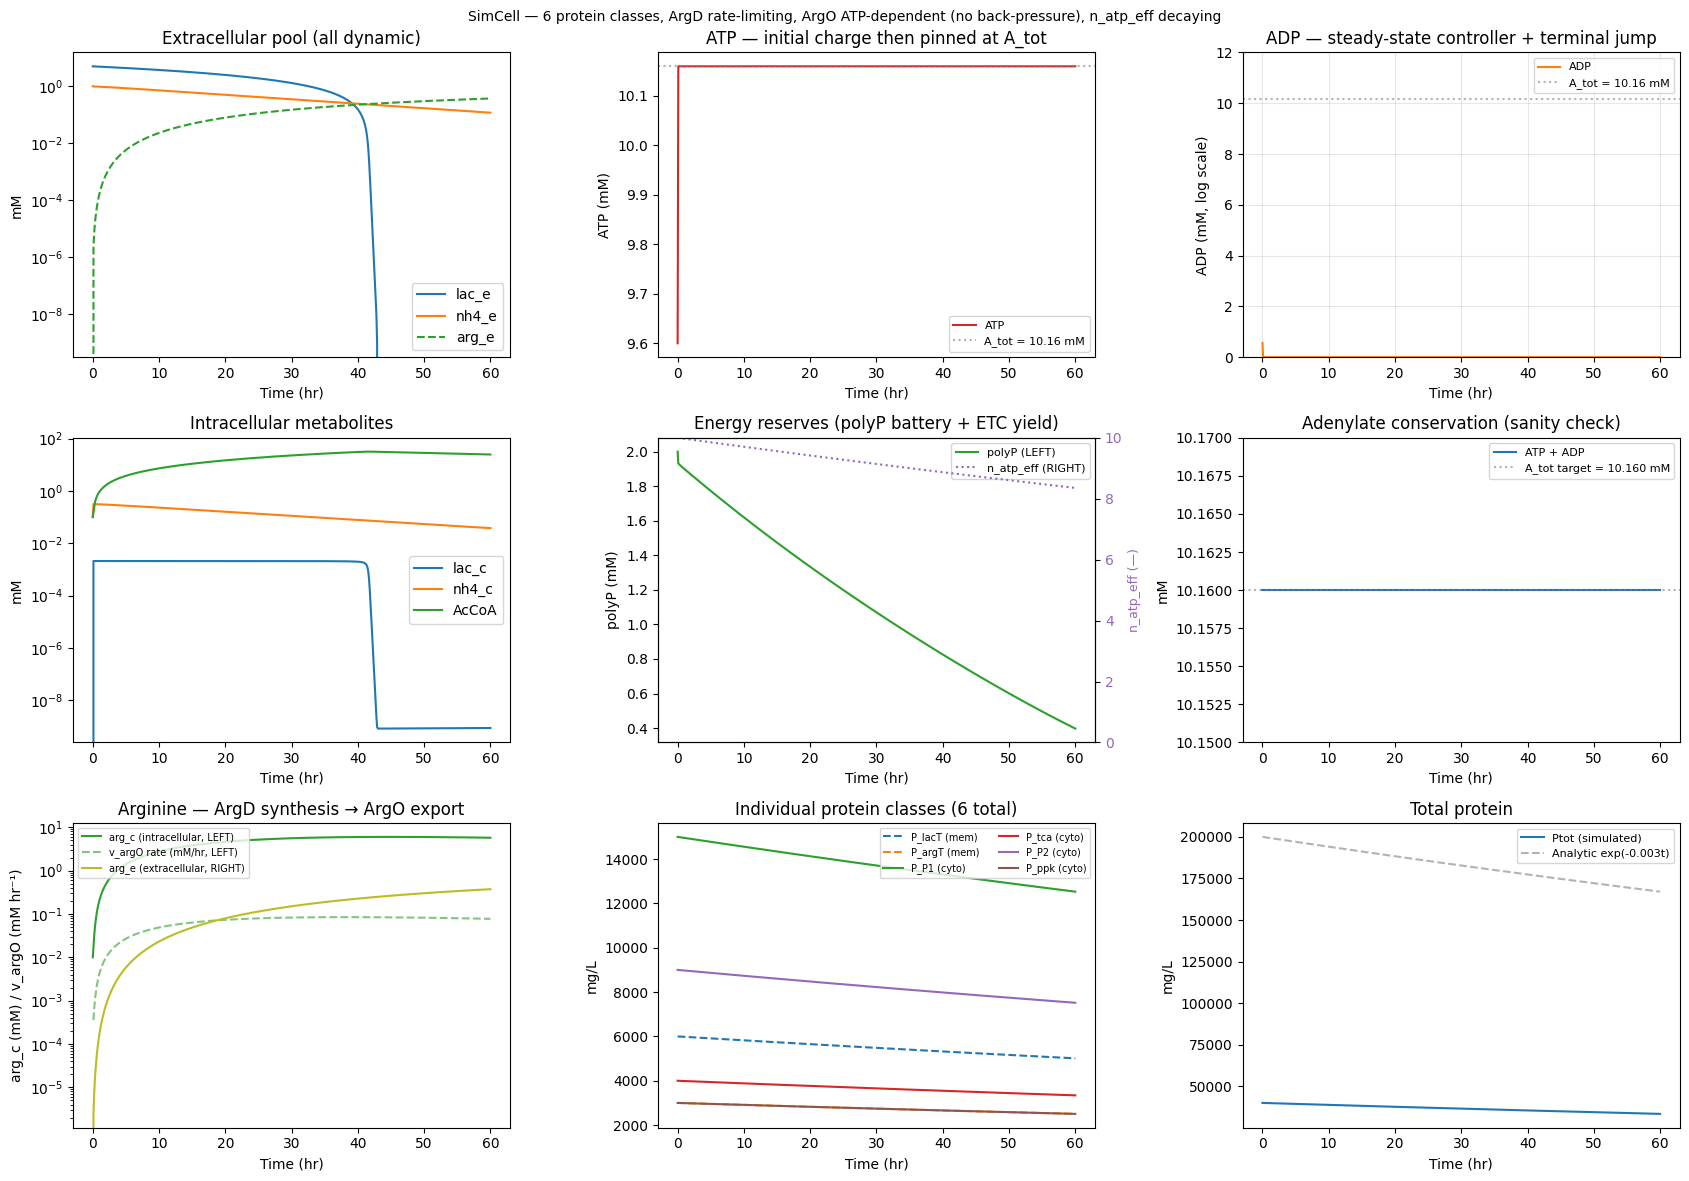

In [10]:
# =============================================================================

if __name__ == "__main__":

    y1_0 = make_y1_0(
        lac_e_0 = 5.0,
        nh4_e_0 = 1.0,
        arg_e_0 = 0.0,
        Ptot0   = 200000.0,
        atp0    = 9.6,
        A_tot   = 10.16,
        polyp0  = 2.0,
    )

    results = run_simcell(
        y1_0  = y1_0,
        T     = 60.0,
        dt    = 0.1,
        r     = 0.01,
        Ke    = 0.5,
        m_ATP = 3,
        verbose = True,
    )

    plot_results(results, Ptot0=200000.0, save_path=str(OUTPUT_DIR / "simcell_results.png"))
